In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("E:\python\Amazon_Products.csv")

In [31]:
# data cleaning processs below

In [4]:
df.head()

,Product_Name,Product_Price,Product_Reviews
0,Apple iPhone 15 (128 GB) - Black,"52,990",4.5
1,iPhone 16e 128 GB: Built for Apple Intelligenc...,"51,499",4.5
2,"POCO C71, Desert Gold (6GB, 128GB)","6,999",4.0
3,"Redmi A4 5G (Sparkle Purple, 4GB RAM, 128GB St...","8,299",4.0
4,OnePlus 15 | 16GB+512GB | Sand Storm | India's...,"79,998",4.5


In [6]:
df.shape

(22, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product_Name     22 non-null     object 
 1   Product_Price    22 non-null     object 
 2   Product_Reviews  22 non-null     float64
dtypes: float64(1), object(2)
memory usage: 660.0+ bytes


In [ ]:
df.drop_duplicates(inplace=True)  #Remove duplicate rows

In [11]:
df.isnull().sum()   #Check missing values null,nan

Product_Name       0
Product_Price      0
Product_Reviews    0
dtype: int64

In [ ]:
df.fillna({'reviews': 0}) # handling missing value in reviews if there is null,nan

,Product_Name,Product_Price,Product_Reviews
0,Apple iPhone 15 (128 GB) - Black,"52,990",4.5
1,iPhone 16e 128 GB: Built for Apple Intelligenc...,"51,499",4.5
2,"POCO C71, Desert Gold (6GB, 128GB)","6,999",4.0
3,"Redmi A4 5G (Sparkle Purple, 4GB RAM, 128GB St...","8,299",4.0
4,OnePlus 15 | 16GB+512GB | Sand Storm | India's...,"79,998",4.5
5,"POCO M7 5G, Mint Green (8GB, 128GB)","9,999",4.1
6,"Samsung Galaxy A55 5G (Awesome Navy, 8GB RAM, ...","26,999",4.3
7,"Samsung Galaxy M07 (Black, 4GB RAM, 64GB Stora...","6,799",4.2
8,Nothing Phone (3a) Black 128GB 8GB RAM,"23,900",4.4
9,"realme NARZO 80 Lite 4G (Beach Gold, 6GB+128GB...","8,299",4.2


In [ ]:
df["Product_Price"] = df["Product_Price"].replace(" ", np.nan) #Replace if there is blank price values with Nan

In [60]:
df["Product_Price"] = df["Product_Price"].astype(str) #converting price from obj to str 
df["Product_Price"] = df["Product_Price"].str.replace(",", "", regex=False) #Remove commas from prices"," 
df["Product_Price"] = df["Product_Price"].astype(int)#Convert product_price to numeric (integer)
df["Product_Reviews"] = df["Product_Reviews"].astype(float)#

In [61]:
df.dtypes

Product_Name         object
Product_Price         int64
Product_Reviews     float64
Price_Range        category
dtype: object

In [ ]:
#creating a new column
# Define price bins and labels
bins = [ 1000, 10000, 20000, 30000, 50000, 100000,200000,300000]
labels = [
    "1k-10k",
    "10k-20k",
    "20k-30k",
    "30k-50k",
    "50k-1lac",
    "1lac-2lac",
    "2lac+"
]

# Create Price Range column
df["Price_Range"] = pd.cut(
    df["Product_Price"],
    bins=bins,
    labels=labels,
    right=False
)

In [70]:
df

,Product_Name,Product_Price,Product_Reviews,Price_Range
0,Apple iPhone 15 (128 GB) - Black,52990,4.0,50k-1lac
1,iPhone 16e 128 GB: Built for Apple Intelligenc...,51499,4.0,50k-1lac
2,"POCO C71, Desert Gold (6GB, 128GB)",6999,4.0,1k-10k
3,"Redmi A4 5G (Sparkle Purple, 4GB RAM, 128GB St...",8299,4.0,1k-10k
4,OnePlus 15 | 16GB+512GB | Sand Storm | India's...,79998,4.0,50k-1lac
5,"POCO M7 5G, Mint Green (8GB, 128GB)",9999,4.0,1k-10k
6,"Samsung Galaxy A55 5G (Awesome Navy, 8GB RAM, ...",26999,4.0,20k-30k
7,"Samsung Galaxy M07 (Black, 4GB RAM, 64GB Stora...",6799,4.0,1k-10k
8,Nothing Phone (3a) Black 128GB 8GB RAM,23900,4.0,20k-30k
9,"realme NARZO 80 Lite 4G (Beach Gold, 6GB+128GB...",8299,4.0,1k-10k


In [32]:
#EDA process below

In [71]:
df.sort_values("Price_Range",ascending=False).head(10)

# Top 10 products from the highest price range

,Product_Name,Product_Price,Product_Reviews,Price_Range
11,iPhone 17 Pro Max 2 TB: 17.42 cm (6.9″) Displa...,229900,4.0,2lac+
10,iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Display ...,154900,4.0,1lac-2lac
20,"iPhone Air 1 TB: Thinnest iPhone Ever, 16.63 c...",150900,3.0,1lac-2lac
21,iPhone 16 Pro Max 256 GB: 5G Mobile Phone with...,134900,4.0,1lac-2lac
4,OnePlus 15 | 16GB+512GB | Sand Storm | India's...,79998,4.0,50k-1lac
1,iPhone 16e 128 GB: Built for Apple Intelligenc...,51499,4.0,50k-1lac
0,Apple iPhone 15 (128 GB) - Black,52990,4.0,50k-1lac
8,Nothing Phone (3a) Black 128GB 8GB RAM,23900,4.0,20k-30k
6,"Samsung Galaxy A55 5G (Awesome Navy, 8GB RAM, ...",26999,4.0,20k-30k
14,OnePlus Nord CE5 | Massive 7100mAh Battery | M...,28999,4.0,20k-30k


In [72]:
df[["Product_Name","Product_Reviews","Price_Range"]].sort_values("Product_Reviews",ascending=False).head(10)

# Top 10 products from the highest Reviews


,Product_Name,Product_Reviews,Price_Range
0,Apple iPhone 15 (128 GB) - Black,4.0,50k-1lac
1,iPhone 16e 128 GB: Built for Apple Intelligenc...,4.0,50k-1lac
2,"POCO C71, Desert Gold (6GB, 128GB)",4.0,1k-10k
3,"Redmi A4 5G (Sparkle Purple, 4GB RAM, 128GB St...",4.0,1k-10k
4,OnePlus 15 | 16GB+512GB | Sand Storm | India's...,4.0,50k-1lac
5,"POCO M7 5G, Mint Green (8GB, 128GB)",4.0,1k-10k
6,"Samsung Galaxy A55 5G (Awesome Navy, 8GB RAM, ...",4.0,20k-30k
7,"Samsung Galaxy M07 (Black, 4GB RAM, 64GB Stora...",4.0,1k-10k
8,Nothing Phone (3a) Black 128GB 8GB RAM,4.0,20k-30k
9,"realme NARZO 80 Lite 4G (Beach Gold, 6GB+128GB...",4.0,1k-10k


In [74]:
price_group = df['Price_Range'].value_counts()

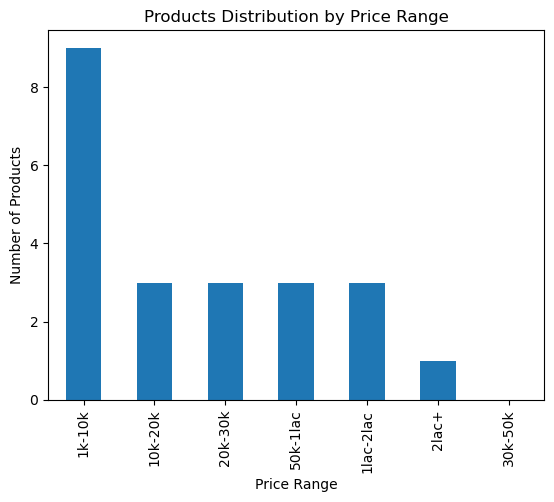

In [ ]:
#Products Count by Price Range

price_group.plot(kind='bar')
plt.title("Products Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")
plt.show()

C:\Users\A\AppData\Local\Temp\ipykernel_19220\604984610.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating = df.groupby('Price_Range')['Product_Price'].mean()


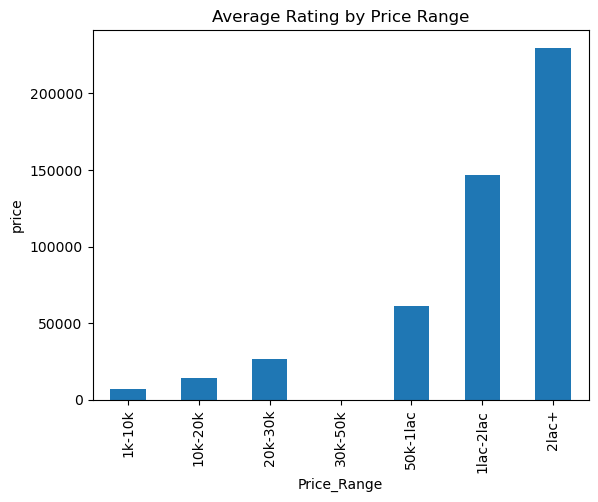

In [89]:
#Average Rating by Price Range

avg_rating = df.groupby('Price_Range')['Product_Price'].mean()
avg_rating.plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.ylabel("price")
plt.show()



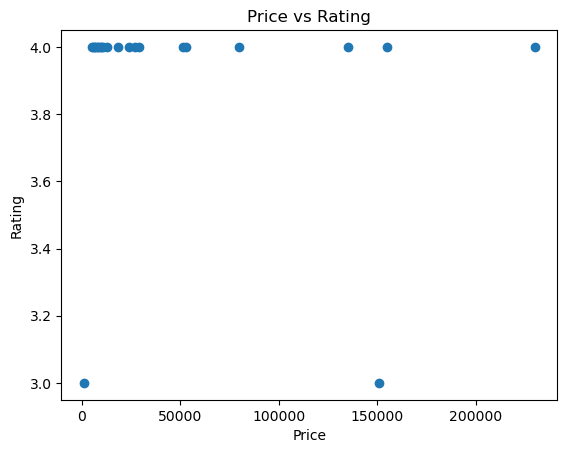

In [85]:
#Price vs Reviews Relationship

plt.scatter(df['Product_Price'], df["Product_Reviews"])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()


In [ ]:
#df.to_csv("Amazon_Products_cleaned file.csv")